# seed iteration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
# Load Data
X = pd.read_csv("/modeling_counts_cpm_tmm_log.csv", index_col=0).T
# X = pd.read_csv("/fs/cbsuvlaminck5/workdir/gfa32/hsct_new/1_DATA/corrected_expr_platelet.tsv", sep = "\t", index_col=0).T

metadata = pd.read_csv("/modeling_metadata.csv", index_col="sample_id", on_bad_lines='skip')

# Extract y (expGroup) and ORIGIN
y = metadata["expGroup"]
origin = metadata["ORIGIN"]

# Create a stratification column combining expGroup & ORIGIN
metadata["stratify_group"] = metadata["expGroup"].astype(str) + "_" + metadata["ORIGIN"].astype(str)


In [4]:
# ── Prepare covariates (run once before the loop) ─────────────────────────────
covariates = metadata[["age", "sex"]].copy()
covariates["sex_binary"] = (covariates["sex"] == "Male").astype(int)
covariates = covariates[["age", "sex_binary"]]   # keep only numeric cols

In [ ]:
# Store results
auc_results = []
classifier_scores_list = []
selected_features_list = []

# Run 100 iterations with different train-test splits
for seed in range(101):
# for seed in range(10):


    print(f"Iteration {seed+1}/100...")

    # Step 1: Stratified train-test split based on expGroup & ORIGIN
    cpm_train, cpm_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=metadata["stratify_group"], random_state=seed
    )

    # Step 2: Remove features where at least 75% of samples in train set have values ≤ 0.5
    mask = (cpm_train > 0.5).sum(axis=0) >= (0.75 * len(cpm_train))  # Keep features where ≥ 25% of values are > 0.5
    cpm_train_filtered = cpm_train.loc[:, mask]

    # Step 3: Subset test set to selected features
    cpm_test_filtered = cpm_test.loc[:, cpm_train_filtered.columns]

    # attach covariates — align by index
    cov_train = covariates.loc[cpm_train_filtered.index]
    cov_test  = covariates.loc[cpm_test_filtered.index]

    cpm_train_filtered = pd.concat([cpm_train_filtered, cov_train], axis=1)
    cpm_test_filtered  = pd.concat([cpm_test_filtered,  cov_test],  axis=1)

    # Step 4: Define LASSO model and cross-validation
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=seed)
    lasso = LogisticRegression(penalty="l1", class_weight="balanced", max_iter=int(1e6), solver="liblinear", random_state=seed)
    lasso_cv = GridSearchCV(lasso, param_grid={"C": np.logspace(-2, 2, 30)}, scoring="roc_auc", cv=cv, n_jobs=20)

    # # Step 5: Preprocessing + Model Pipeline
    # preprocessing = Pipeline([
    #     ("variance", VarianceThreshold(0.5)),
    #     ("std", StandardScaler()),
    #     ("impute", SimpleImputer(strategy="median"))
    # ])
    
    pipeline = Pipeline([
        ("lasso_cv", lasso_cv)
    ])

    # Train the model
    pipeline.fit(cpm_train_filtered, y_train)

    # Step 6: Get best model and make predictions
    best_lasso = pipeline.named_steps["lasso_cv"].best_estimator_

    # Predict probabilities for train & test sets
    train_probs = best_lasso.predict_proba(cpm_train_filtered)[:, 1]
    test_probs = best_lasso.predict_proba(cpm_test_filtered)[:, 1]

    # Calculate AUC and store results
    test_auc = roc_auc_score(y_test, test_probs)
    auc_results.append(test_auc)

    ### 🔹 Save Classifier Scores (Train & Test)
    df_train = pd.DataFrame({
        "sample_id": cpm_train_filtered.index,
        "iteration": seed,
        "train_or_test": "train",
        "classifier_score": train_probs
    })

    df_test = pd.DataFrame({
        "sample_id": cpm_test_filtered.index,
        "iteration": seed,
        "train_or_test": "test",
        "classifier_score": test_probs
    })

    # Append to full classifier scores list
    classifier_scores_list.append(pd.concat([df_train, df_test]))

    ### 🔹 Save Selected Features & Coefficients
    selected_features = cpm_train_filtered.columns[best_lasso.coef_.flatten() != 0]
    selected_coefficients = best_lasso.coef_.flatten()[best_lasso.coef_.flatten() != 0]

    df_features = pd.DataFrame({
        "iteration": seed,
        "feature": selected_features,
        "coefficient": selected_coefficients
    })

    # Append to selected features list
    selected_features_list.append(df_features)

# Convert lists to DataFrames
classifier_scores_df = pd.concat(classifier_scores_list, ignore_index=True)
selected_features_df = pd.concat(selected_features_list, ignore_index=True)

# Save to CSV
classifier_scores_df.to_csv("/classifier_scores.csv", index=False)
selected_features_df.to_csv("/selected_features.csv", index=False)

print("\n✅ Saved classifier scores & selected features!")



Iteration 1/100...
Iteration 2/100...
Iteration 3/100...
Iteration 4/100...
Iteration 5/100...
Iteration 6/100...
Iteration 7/100...
Iteration 8/100...
Iteration 9/100...
Iteration 10/100...
Iteration 11/100...
Iteration 12/100...
Iteration 13/100...
Iteration 14/100...
Iteration 15/100...
Iteration 16/100...
Iteration 17/100...
Iteration 18/100...
Iteration 19/100...
Iteration 20/100...
Iteration 21/100...
Iteration 22/100...
Iteration 23/100...
Iteration 24/100...
Iteration 25/100...
Iteration 26/100...
Iteration 27/100...
Iteration 28/100...
Iteration 29/100...
Iteration 30/100...
Iteration 31/100...
Iteration 32/100...
Iteration 33/100...
Iteration 34/100...
Iteration 35/100...
Iteration 36/100...
Iteration 37/100...
Iteration 38/100...
Iteration 39/100...
Iteration 40/100...
Iteration 41/100...
Iteration 42/100...
Iteration 43/100...
Iteration 44/100...
Iteration 45/100...
Iteration 46/100...
Iteration 47/100...
Iteration 48/100...
Iteration 49/100...
Iteration 50/100...
Iteration


Test AUC Summary:
count    101.000000
mean       0.747816
std        0.096797
min        0.460784
25%        0.691176
50%        0.754902
75%        0.808824
max        0.960784
Name: Test_AUC, dtype: float64


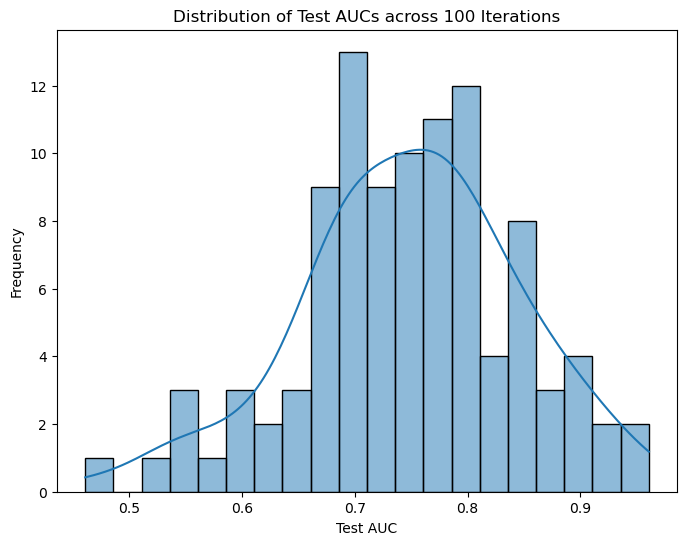

In [ ]:
# Convert results to DataFrame
auc_df = pd.DataFrame({"Iteration": np.arange(1, 102), "Test_AUC": auc_results})
# auc_df = pd.DataFrame({"Iteration": np.arange(1, 11), "Test_AUC": auc_results})


# Save results to CSV
auc_df.to_csv("/lasso_test_auc_results.csv", index=False)

# Print summary statistics
print("\nTest AUC Summary:")
print(auc_df["Test_AUC"].describe())

# Plot AUC Distribution
plt.figure(figsize=(8, 6))
sns.histplot(auc_df["Test_AUC"], bins=20, kde=True)
plt.xlabel("Test AUC")
plt.ylabel("Frequency")
plt.title("Distribution of Test AUCs across 100 Iterations")
plt.show()

In [11]:
median_value = auc_df["Test_AUC"].median()
median_row = auc_df[auc_df["Test_AUC"] == median_value]

median_row

,Iteration,Test_AUC
10,11,0.754902


In [7]:
auc_df

,Iteration,Test_AUC
0,1,0.553922
1,2,0.647059
2,3,0.759804
3,4,0.745098
4,5,0.622549
...,...,...
96,97,0.803922
97,98,0.818627
98,99,0.843137
99,100,0.720588
